# Isolation Forest Run

In [6]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

In [7]:
# Fake Student Data 
# Represents the reflection statistics.
data = {
    "word_count": [
        45, 52, 38, 61, 49, 55, 42, 47, 58, 51,
        46, 53, 44, 50, 57, 48, 41, 54, 60, 43,
        3, 4, 2, 5, 150
    ],
    "exclamation_count": [
        1, 0, 2, 1, 0, 1, 0, 1, 2, 0,
        1, 0, 1, 1, 0, 2, 1, 0, 1, 0,
        0, 0, 0, 0, 20
    ]
}

df = pd.DataFrame(data)

df.head()

,word_count,exclamation_count
0,45,1
1,52,0
2,38,2
3,61,1
4,49,0


In [8]:
df.shape

(25, 2)

* We are expecting most students to have reflections around 40-60 words and 0-2 exclamation marks.

* The last few observations are deliberately strange. Our potential anomalies make up 20% of the data.

In [9]:
df.tail()

,word_count,exclamation_count
20,3,0
21,4,0
22,2,0
23,5,0
24,150,20


### Plot the Data

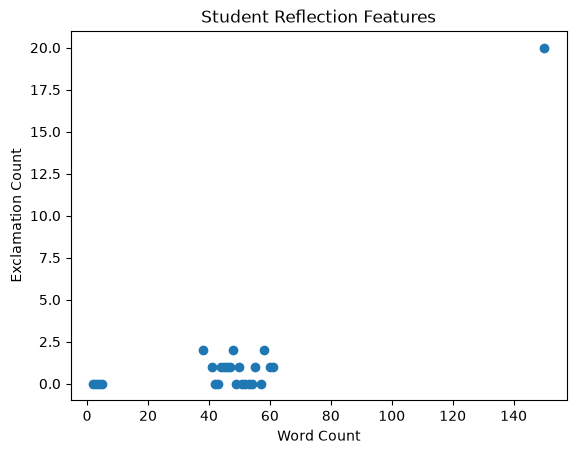

In [10]:
plt.scatter(df["word_count"], df["exclamation_count"])

plt.xlabel("Word Count")
plt.ylabel("Exclamation Count")
plt.title("Student Reflection Features")
plt.show()

### Isolation Forest

* An isolation Forest asks "Which observations are unusually easy to separate from the rest of the data?"

In [11]:
X = df[['word_count', 'exclamation_count']]
X

,word_count,exclamation_count
0,45,1
1,52,0
2,38,2
3,61,1
4,49,0
5,55,1
6,42,0
7,47,1
8,58,2
9,51,0


In [ ]:
# Contamination = 0.2, tells the model that I'm roughly expecting 20% of the observations to be anomalies.
model = IsolationForest(
  contamination=0.2, 
  random_state=42
)

model.fit(X)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


* In bigger datasets, we'd determine an appropriate threshold based on the problem, labels, validation data, and operational costs.

In [13]:
# Get anomaly predictions.
# 1 = normal
# -1 = anomaly

df['prediction'] = model.predict(X)
df

,word_count,exclamation_count,prediction
0,45,1,1
1,52,0,1
2,38,2,-1
3,61,1,1
4,49,0,1
5,55,1,1
6,42,0,1
7,47,1,1
8,58,2,-1
9,51,0,1


In [15]:
df['is_anomaly'] = (df['prediction'] == -1)
df

,word_count,exclamation_count,prediction,is_anomaly
0,45,1,1,False
1,52,0,1,False
2,38,2,-1,True
3,61,1,1,False
4,49,0,1,False
5,55,1,1,False
6,42,0,1,False
7,47,1,1,False
8,58,2,-1,True
9,51,0,1,False


In [16]:
df[df["is_anomaly"]]

,word_count,exclamation_count,prediction,is_anomaly
2,38,2,-1,True
8,58,2,-1,True
22,2,0,-1,True
23,5,0,-1,True
24,150,20,-1,True


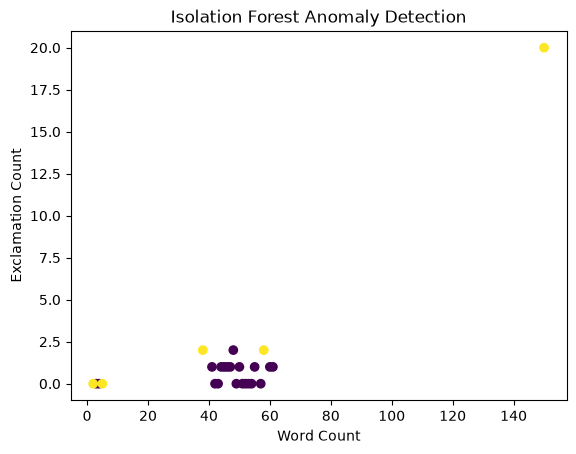

In [17]:
plt.scatter(
    df["word_count"],
    df["exclamation_count"],
    c=df["is_anomaly"]
)

plt.xlabel("Word Count")
plt.ylabel("Exclamation Count")
plt.title("Isolation Forest Anomaly Detection")
plt.show()

### Anomaly Scores

* lower score → more anomalous

* higher score → more normal



In [18]:
df["anomaly_score"] = model.decision_function(X)

df.sort_values("anomaly_score")

,word_count,exclamation_count,prediction,is_anomaly,anomaly_score
24,150,20,-1,True,-0.320024
22,2,0,-1,True,-0.042689
2,38,2,-1,True,-0.036984
8,58,2,-1,True,-0.033628
23,5,0,-1,True,-0.026938
21,4,0,1,False,0.006735
20,3,0,1,False,0.007383
15,48,2,1,False,0.012154
3,61,1,1,False,0.040673
14,57,0,1,False,0.050661


In [19]:
# Look at the observations flagged as anomalies

anomalies = df[df["is_anomaly"]].copy()

anomalies.sort_values("anomaly_score")

,word_count,exclamation_count,prediction,is_anomaly,anomaly_score
24,150,20,-1,True,-0.320024
22,2,0,-1,True,-0.042689
2,38,2,-1,True,-0.036984
8,58,2,-1,True,-0.033628
23,5,0,-1,True,-0.026938


* Why were these observations flagged?

  - Likely because the students here wrote unusually short reflections or really long ones.

In [20]:
# Compare agionst the normal baseline.
normal = df[df["prediction"] == 1]

print("Normal average word count:",
      normal["word_count"].mean())

print("Anomaly average word count:",
      anomalies["word_count"].mean())

Normal average word count: 45.25
Anomaly average word count: 50.6


In [21]:
print("Number of anomalies:", len(anomalies))
print("Percentage anomalous:", len(anomalies) / len(df))

Number of anomalies: 5
Percentage anomalous: 0.2


### Check whether it's an isolated anomaly or a broader shift

* If we suddenly went from:
  - Normally: ~5% unusual reflections

  - Today:    ~30% unusual reflections

* I'd investigate whether something changed in the data-generating process. This could be data drift, rather than a handful of individual anomalies.

* New assignment or teacher prompt instructions changed?

* New student population?

* Seasonal behavior?

### NEXT STEPS
#
* 1. Inspect the observations flagged as anomalies.

* 2. Determine whether they represent real unusual behavior or a data-quality / pipeline issue.

* 3. Compare anomaly rates and feature distributions against a historical baseline.

* 4. If ground-truth labels are available, evaluate the model using precision, recall, and F1.

* 5. Tune the anomaly threshold based on the cost of false positives vs. false negatives.

* 6. If the anomalies represent a legitimate new pattern, collect and label representative examples.

* 7. Consider updating/retraining the model if the new pattern is important and persistent.

* 8. Monitor the anomaly rate and feature distributions in production over time.